# Meat Consumption Around the World: Trends and Differences Across Continents

In [3]:
!pip install kagglehub

  Using cached kagglehub-1.0.2-py3-none-any.whl.metadata (40 kB)
  Using cached kagglesdk-0.1.37-py3-none-any.whl.metadata (13 kB)
Using cached kagglehub-1.0.2-py3-none-any.whl (70 kB)
Using cached kagglesdk-0.1.37-py3-none-any.whl (262 kB)

   ---------------------------------------- 0/4 [tqdm]
   ---------- ----------------------------- 1/4 [protobuf]
   ---------- ----------------------------- 1/4 [protobuf]
   ---------- ----------------------------- 1/4 [protobuf]
   -------------------- ------------------- 2/4 [kagglesdk]
   -------------------- ------------------- 2/4 [kagglesdk]
   -------------------- ------------------- 2/4 [kagglesdk]
   -------------------- ------------------- 2/4 [kagglesdk]
   -------------------- ------------------- 2/4 [kagglesdk]
   -------------------- ------------------- 2/4 [kagglesdk]
   ------------------------------ --------- 3/4 [kagglehub]
   ---------------------------------------- 4/4 [kagglehub]



  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [1]:
import kagglehub
import os
import pandas as pd
import requests
import time


In [9]:
def format_columns(df):
    df = df.copy()

    df.columns = (
        df.columns
        .str.striformat_columnsp()
        .str.lower()
        .str.replace(" ", "_")
        .str.replace(r"[^\w]", "", regex=True)
    )

    return df

In [10]:
def quick_analysis(df):

    print("=" * 50)
    print("QUICK DATA ANALYSIS")
    print("=" * 50)

    print("\n📐 SHAPE")
    print(df.shape)

    print("\n📋 COLUMNS")
    print(df.columns.tolist())

    print("\n👀 FIRST 5 ROWS")
    display(df.head())

    print("\n🔎 INFO")
    df.info()

    print("\n❓ MISSING VALUES")
    print(df.isnull().sum())

    print("\n🔁 DUPLICATES")
    print(df.duplicated().sum())

    print("\n📊 DESCRIPTIVE STATISTICS")
    display(df.describe())


### Worldwide Meat Consumption - Kaggle

https://www.kaggle.com/datasets/vagifa/meatconsumption

https://data.oecd.org/agroutput/meat-consumption.htm OECD/FAO (2017), “OECD-FAO Agricultural Outlook”, OECD Agriculture statistics (database). doi: dx.doi.org/10.1787/agr-outl-data-en (Accessed on 24 January 2018)

In [ ]:
# Download latest version
path = kagglehub.dataset_download("vagifa/meatconsumption")

file_path = os.path.join(path,os.listdir(path)[0])

worldwide_meat_consumption = pd.read_csv(file_path)

In [ ]:
worldwide_meat_consumption = format_columns(worldwide_meat_consumption)

In [ ]:
quick_analysis(worldwide_meat_consumption)

In [ ]:
worldwide_meat_consumption["location"].unique()

In [ ]:
worldwide_meat_consumption["subject"].unique()

In [ ]:
worldwide_meat_consumption["measure"].unique()

In [ ]:
# New table ust with the measure of Kg per Capita

worldwide_meat_consumption_cap = worldwide_meat_consumption[worldwide_meat_consumption["measure"] == "KG_CAP"]

worldwide_meat_consumption_cap.shape

In [ ]:
worldwide_meat_consumption_cap["time"].unique()

In [ ]:
worldwide_meat_consumption_cap["time"].min()

In [ ]:
worldwide_meat_consumption_cap["time"].max()

In [ ]:
worldwide_meat_consumption_cap["subject"].value_counts()

In [ ]:
worldwide_meat_consumption_cap.groupby("subject")["value"].mean()

In [ ]:
meat_consumption_world = worldwide_meat_consumption_cap[worldwide_meat_consumption_cap["location"] == "WLD"]

meat_consumption_world.shape

In [ ]:
meat_consumption_world.head()

In [ ]:
meat_consumption_world.groupby("subject")["value"].mean()

**<u>Conclusions:</u>**

**Range of time:** 1990 - 2026

**Types of meat:** Beef, pig, poultry, sheep

**Mean of meat consumpition in the world per type:**

| Type         | Mean (kg per capita)|
|--------------|---------------------|
| POULTRY      | 11.721474           |
| BEEF         | 6.575449            |
| PIG          | 11.851163           |
| SHEEP        | 1.687124            |





<u>Este data é bom para estudar a nivel mundial mas nao a nivel de paises. Tem conjutos como OECD, BRICS que vão repetir-se entre listas.</u>

### Meat prices (1990-2020) - Kaggle

https://www.kaggle.com/datasets/kianwee/meat-prices-19902020

Data is obtained from Indexmundi.

In [ ]:
# Download latest version
path_1 = kagglehub.dataset_download("kianwee/meat-prices-19902020")

file_path_1 = os.path.join(path_1,os.listdir(path_1)[0])

meat_prices = pd.read_csv(file_path_1)

In [ ]:
meat_prices = format_columns(meat_prices)

In [ ]:
quick_analysis(meat_prices)

### Global Vegetarian Index

https://www.kaggle.com/datasets/jamessuryaputra/global-vegetarian-index

In [5]:
# Download latest version
path_2 = kagglehub.dataset_download("jamessuryaputra/global-vegetarian-index")

file_path_2 = os.path.join(path_2,os.listdir(path_2)[0])

global_vegetarian_index = pd.read_csv(file_path_2)

In [12]:
global_vegetarian_index = format_columns(global_vegetarian_index)

AttributeError: 'StringMethods' object has no attribute 'striformat_columnsp'

In [13]:
quick_analysis(global_vegetarian_index)

QUICK DATA ANALYSIS

📐 SHAPE
(21, 6)

📋 COLUMNS
['Global Vegetarian Index', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5']

👀 FIRST 5 ROWS


,Global Vegetarian Index,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5
0,Country,Annual meat consumption (lb-oz),No. of vegetarian restaurants,No. of people per locations,Global Vegetarian Index Score,NaN
1,Seychelles,78.5,117,810,328,NaN
2,Thailand,56.9,908,"76,000",326,NaN
3,Malaysia,115.3,"1,185","27,000",311,NaN
4,Sao Tome & Principe,36.4,13,"16,000",311,NaN



🔎 INFO
<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Global Vegetarian Index  21 non-null     str    
 1   Unnamed: 1               21 non-null     str    
 2   Unnamed: 2               21 non-null     str    
 3   Unnamed: 3               21 non-null     str    
 4   Unnamed: 4               21 non-null     str    
 5   Unnamed: 5               0 non-null      float64
dtypes: float64(1), str(5)
memory usage: 1.7 KB

❓ MISSING VALUES
Global Vegetarian Index     0
Unnamed: 1                  0
Unnamed: 2                  0
Unnamed: 3                  0
Unnamed: 4                  0
Unnamed: 5                 21
dtype: int64

🔁 DUPLICATES
0

📊 DESCRIPTIVE STATISTICS


,Unnamed: 5
count,0.0
mean,NaN
std,NaN
min,NaN
25%,NaN
50%,NaN
75%,NaN
max,NaN


### Yearly number of animals slaughtered for meat (Europe, 1961 to 2024)

https://ourworldindata.org/grapher/animals-slaughtered-for-meat?country=~OWID_EUR

In [ ]:
# Fetch the data.
animals_data = pd.read_csv("https://ourworldindata.org/grapher/animals-slaughtered-for-meat.csv?v=1&csvType=full&useColumnShortNames=true", storage_options = {'User-Agent': 'Our World In Data data fetch/1.0'})

In [ ]:
animals_data = format_columns(animals_data)

In [ ]:
quick_analysis(animals_data)

### Daily meat consumption per person

https://ourworldindata.org/grapher/daily-meat-consumption-per-person

In [ ]:
# Fetch the data.
consumption_per_person = pd.read_csv("https://ourworldindata.org/grapher/daily-meat-consumption-per-person.csv?v=1&csvType=full&useColumnShortNames=true", storage_options = {'User-Agent': 'Our World In Data data fetch/1.0'})

In [ ]:
consumption_per_person = format_columns(consumption_per_person)

In [ ]:
quick_analysis(consumption_per_person)

In [ ]:
print(consumption_per_person["code"].unique().tolist())

In [ ]:
consumption_per_person[
    consumption_per_person["code"].isin(
        ["OWID_AFR", "OWID_EUR", "OWID_ASI", "OWID_NAM", "OWID_SAM", "OWID_WRL"]
    )
].groupby("code")["meat__total__00002943__food_available_for_consumption__0645pe__grams_per_day_per_capita"].mean()



In [ ]:
consumption_per_person[consumption_per_person["code"].isin(["OWID_AFR", "OWID_EUR","OWID_ASI","OWID_NAM","OWID_NAM","OWID_SAM","OWID_WRL"])]

In [ ]:
consumption_per_person[consumption_per_person["code"].isin(["OWID_ASI"])]

### Daily supply of different food groups per person

https://ourworldindata.org/grapher/per-capita-diet-composition

In [ ]:
food_group_consumption = pd.read_csv("https://ourworldindata.org/grapher/per-capita-diet-composition.csv?v=1&csvType=full&useColumnShortNames=true", storage_options = {'User-Agent': 'Our World In Data data fetch/1.0'})

In [ ]:
food_group_consumption = format_columns(food_group_consumption)

In [ ]:
quick_analysis(food_group_consumption)

## Meat supply vs. GDP per capita

In [2]:
# Fetch the data.
df = pd.read_csv("https://ourworldindata.org/grapher/meat-consumption-vs-gdp-per-capita.csv?v=1&csvType=full&useColumnShortNames=true", storage_options = {'User-Agent': 'Our World In Data data fetch/1.0'})

### API's

In [7]:
def fetch_meat_data():
    
    url = "https://ourworldindata.org/grapher/per-capita-meat-type.csv"
    
    params = {
        "csvType": "filtered",
        "country": "OWID_AFR~OWID_ASI~OWID_EUR~OWID_NAM~OWID_OCE~OWID_SAM~PRT~USA"
    }
    
    try:
        response = requests.get(url, params=params, timeout=30)
        response.raise_for_status()
        
        data = pd.read_csv(
            pd.io.common.StringIO(response.text)
        )
        
        return data
    
    except requests.exceptions.RequestException as error:
        print(f"Error fetching data: {error}")
        return None

In [8]:
meat_api = fetch_meat_data()

meat_api.head()

,Entity,Code,Year,Poultry,Beef and buffalo,Sheep and goat,Pork,Other meats,Fish and seafood
0,Africa,OWID_AFR,2023,7.021459,4.696550,1.892605,1.755845,1.301518,9.255091
1,Asia,OWID_ASI,2023,12.713380,5.800276,2.812343,15.401421,0.417878,23.890427
2,Europe,OWID_EUR,2023,27.242353,13.448068,1.588957,34.826897,1.527611,21.640440
3,North America,OWID_NAM,2023,46.928528,27.941734,0.625071,24.652290,0.652107,18.365635
4,Oceania,OWID_OCE,2023,37.564354,18.564447,8.364254,19.979510,10.670967,21.070915


In [ ]:
meat_api[
    meat_api["Code"].isin([
        "OWID_AFR", "OWID_EUR", "OWID_ASI", "OWID_NAM", "OWID_SAM"
    ])
].groupby("Code")[
    ["Poultry", "Beef and buffalo", "Sheep and goat", "Pork", "Other meats", "Fish and seafood"]
].mean()



,Poultry,Beef and buffalo,Sheep and goat,Pork,Other meats,Fish and seafood
Code,,,,,,
OWID_AFR,7.021459,4.696550,1.892605,1.755845,1.301518,9.255091
OWID_ASI,12.713380,5.800276,2.812343,15.401421,0.417878,23.890427
OWID_EUR,27.242353,13.448068,1.588957,34.826897,1.527611,21.640440
OWID_NAM,46.928528,27.941734,0.625071,24.652290,0.652107,18.365635
OWID_SAM,41.940630,29.718420,0.693802,14.964857,0.603328,9.817036


In [15]:
total = (
    meat_api[
        meat_api["Code"].isin([
            "OWID_AFR", "OWID_EUR", "OWID_ASI",
            "OWID_NAM", "OWID_SAM"
        ])
    ]
    .groupby("Code")[
        ["Poultry", "Beef and buffalo", "Sheep and goat",
         "Pork", "Other meats", "Fish and seafood"]
    ]
    .mean()
)

total["Total"] = total.sum(axis=1)

total.round(2)

,Poultry,Beef and buffalo,Sheep and goat,Pork,Other meats,Fish and seafood,Total
Code,,,,,,,
OWID_AFR,7.02,4.70,1.89,1.76,1.30,9.26,25.92
OWID_ASI,12.71,5.80,2.81,15.40,0.42,23.89,61.04
OWID_EUR,27.24,13.45,1.59,34.83,1.53,21.64,100.27
OWID_NAM,46.93,27.94,0.63,24.65,0.65,18.37,119.17
OWID_SAM,41.94,29.72,0.69,14.96,0.60,9.82,97.74


In [1]:
pip install country_converter

Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


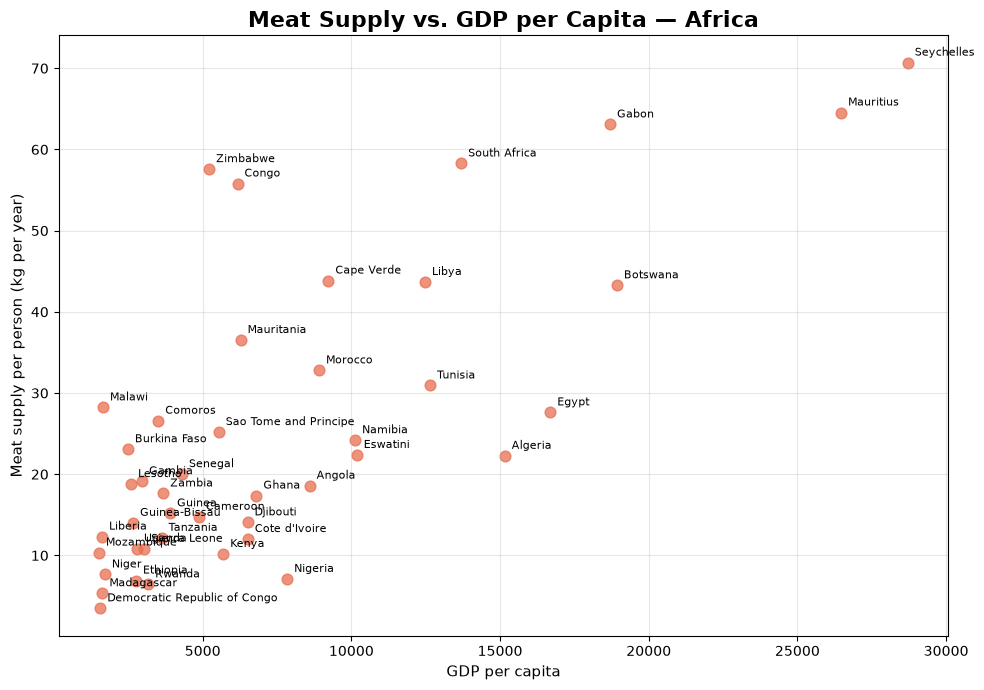

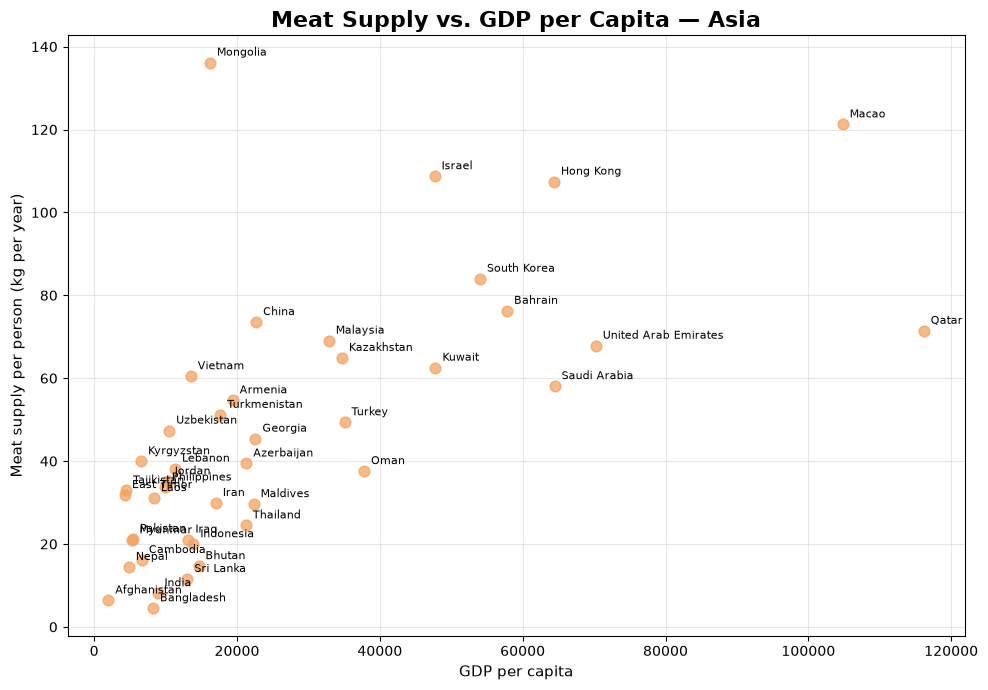

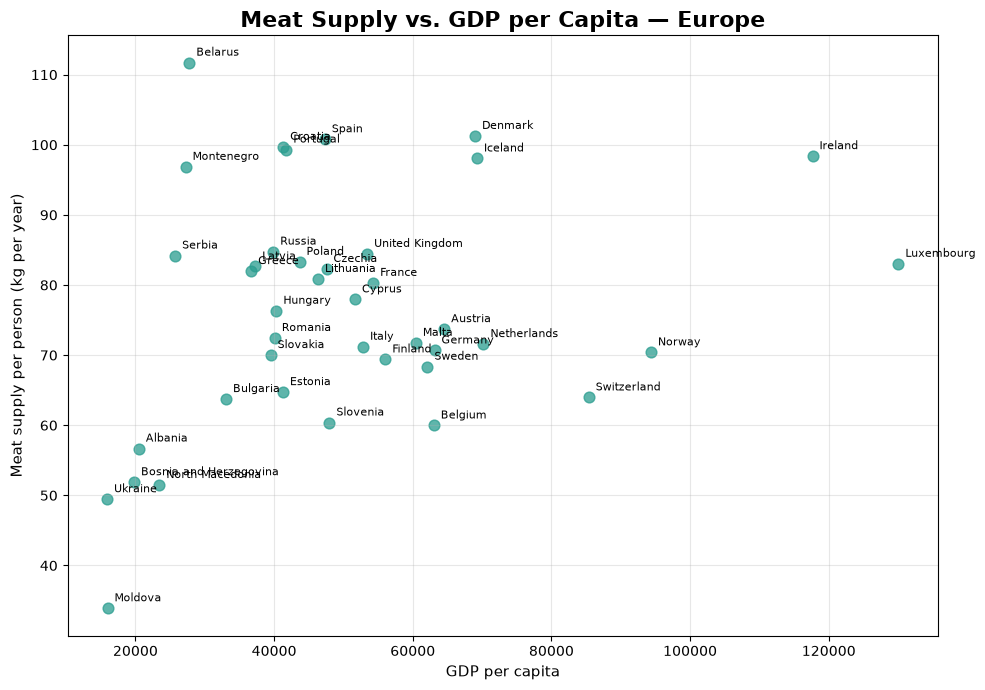

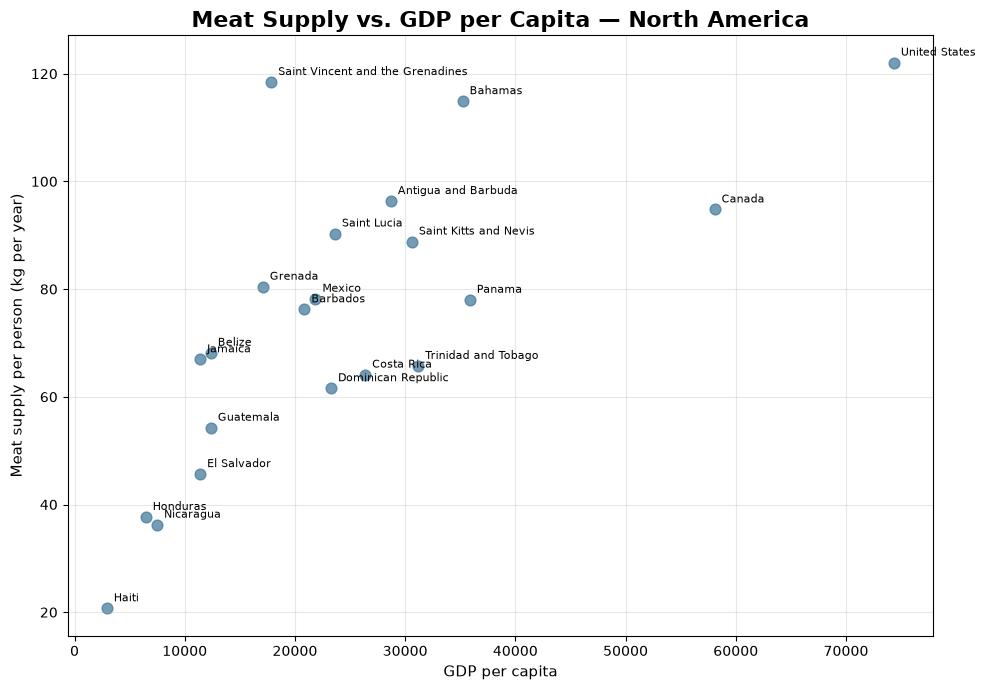

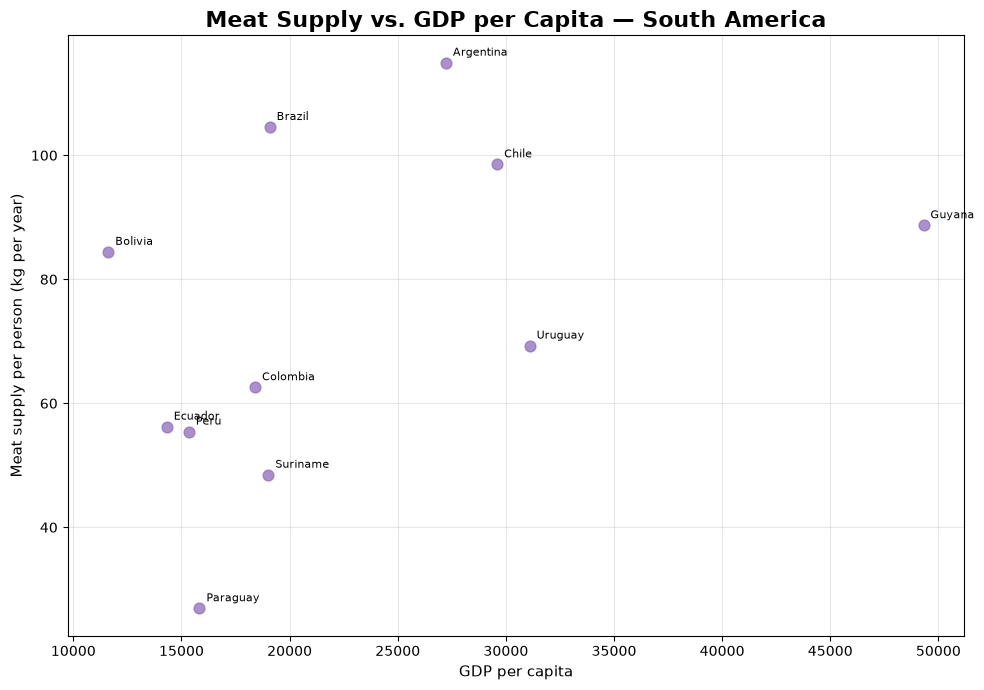

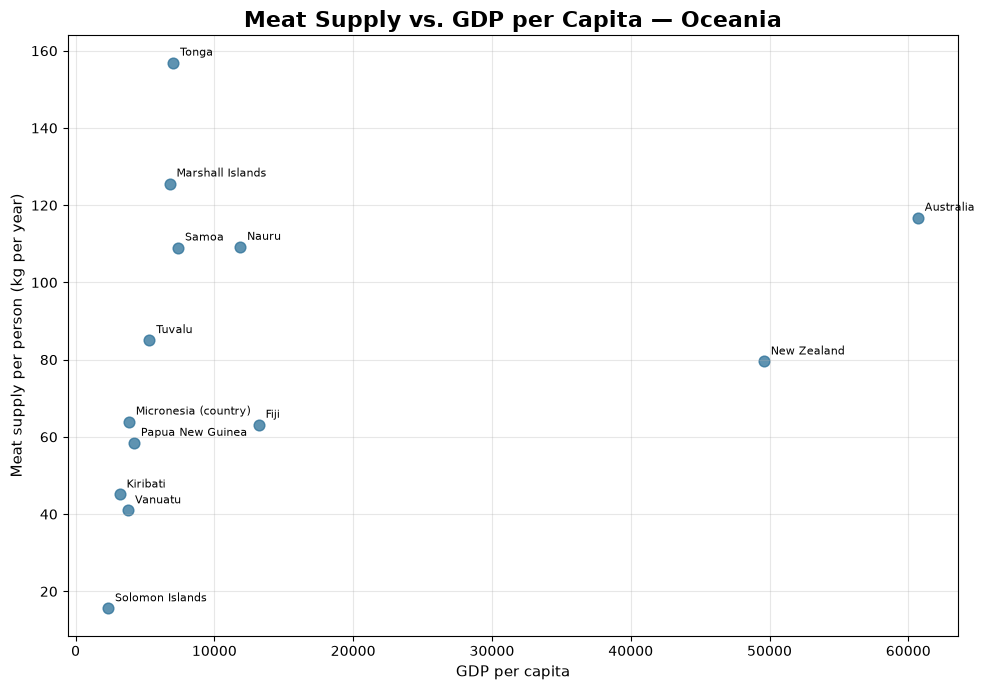

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Keep only 2023
df_2023 = df[df["Year"] == 2023].copy()

# Continents
continents = [
    "Africa",
    "Asia",
    "Europe",
    "North America",
    "South America",
    "Oceania"
]

# Different color for each continent
colors = {
    "Africa": "#E76F51",
    "Asia": "#F4A261",
    "Europe": "#2A9D8F",
    "North America": "#457B9D",
    "South America": "#8E6CBE",
    "Oceania": "#2A6F97"
}

# Create one scatter plot for each continent
for continent in continents:

    continent_data = df_2023[
        df_2023["World region according to OWID"] == continent
    ].copy()

    plt.figure(figsize=(10, 7))

    # Scatter plot
    plt.scatter(
        continent_data["GDP per capita"],
        continent_data["Meat supply per person"],
        s=60,
        alpha=0.75,
        color=colors[continent]
    )

    # Add country names
    for _, row in continent_data.iterrows():

        plt.annotate(
            row["Entity"],
            (
                row["GDP per capita"],
                row["Meat supply per person"]
            ),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=8
        )

    # Title
    plt.title(
        f"Meat Supply vs. GDP per Capita — {continent}",
        fontsize=16,
        fontweight="bold"
    )

    # Axis labels
    plt.xlabel(
        "GDP per capita",
        fontsize=11
    )

    plt.ylabel(
        "Meat supply per person (kg per year)",
        fontsize=11
    )

    # Grid
    plt.grid(
        True,
        alpha=0.3
    )

    plt.tight_layout()

    plt.show()

In [4]:
print(df.columns.tolist())


['Entity', 'Code', 'Year', 'Meat supply per person', 'GDP per capita', 'World region according to OWID']
